 Naver open API를 활용하여 네이버지식인 "전주여행"과 "경주여행"을 검색
 -> 명사만 추출(re?) -> 빈도분석(DataFrame) -> 빈도 시각화(워드클라우드, Text)
 -> Word2Vec

# 1. 네이버 open API를 활용하여 검색 추출
- 검색어, no, title, link, description, title + ' ' + description

In [1]:
import urllib.request
import requests
import sys
import pandas as pd
from dotenv import load_dotenv
import os
from bs4 import BeautifulSoup
    
load_dotenv()

def get_naver_kin(keyword, cnt):
    
     
    client_id = os.getenv('Client_ID')
    client_secret = os.getenv('Client_Secret')

    url = f'https://openapi.naver.com/v1/search/kin.json?query={keyword}&display={cnt}'
    headers = {'X-Naver-Client-Id': client_id,
               'X-Naver-Client-Secret':client_secret}
    response = requests.get(url, headers=headers)

    items = response.json()['items']
    items_list = []
    for item in items:
        items_list.append([
            item.get('title').replace('<b>','').replace('</b>',''),
            item.get('link'),
            item.get('description').replace('<b>','').replace('</b>','')
        ])
    return pd.DataFrame(items_list, columns=['title','link','description'])

df_jeonju = get_naver_kin("전주여행", 30)
df_gyeongju = get_naver_kin("경주여행", 30)

df_jeonju['text'] = df_jeonju['title'] + ' ' + df_jeonju['description']
df_gyeongju['text'] = df_gyeongju['title'] + ' ' + df_gyeongju['description']

print("전주여행 검색 :", df_jeonju['text'].iloc[0])
print("경주여행 검색 :", df_gyeongju['text'].iloc[0])


전주여행 검색 : 전주 가볼만한곳 추천 받아요 ... 추억의 7080 #다양한체험 #7080감성 #추억여행 #테마박물관 #유익한시간 2. [전북] 전북투어패스 통합이용권 #전북핫플 #여러여행지 #다양한체험 #카페이용추가 #전주여행필수 편안하고 즐거운 날이 되시길 바라겠습니다. 감사합니다 :)
경주여행 검색 : 추석에 경주 여행 추석에 경주 여행 가는거 어떻게 생각하시나요? 서울에서 버스를 타고 갈 경우, 버스가 버스전용 차선에서 운행하나요?... 질문하신 [추석 경주여행] 관련 답변 드리도록 하겠습니다. 첨성대, 석굴암, 불국사 등 유적지는 연중무휴로... 


In [3]:
get_naver_kin("경주여행",5)

,title,link,description
0,추석에 경주 여행,https://kin.naver.com/qna/detail.naver?d1id=9&...,"추석에 경주 여행 가는거 어떻게 생각하시나요? 서울에서 버스를 타고 갈 경우, 버스..."
1,1박2일 경주 여행 일정 짜주세요,https://kin.naver.com/qna/detail.naver?d1id=9&...,"1박2일 경주 여행 일정 짜주세요 질문자님, 경주에서의 1박 2일 여행을 계획 중이..."
2,어머니랑 1박2일 경주여행,https://kin.naver.com/qna/detail.naver?d1id=9&...,이제 5월달 어버이날을 위해 어머니랑 경주 여행을 할려고합니다 ㅎㅎ 놀러갈데는 다 ...
3,경주 여행,https://kin.naver.com/qna/detail.naver?d1id=9&...,"5월6,7,8일 경주 여행을 가는데요 동궁과월지와 월정교 야경을 보고 싶은데 7일에..."
4,경주여행 30만원,https://kin.naver.com/qna/detail.naver?d1id=9&...,경주 여행 2박3일 남자친구랑 가는데 숙소랑 ktx비는 다 냈고 제 개인적으로 30...


In [4]:
# 방법1 (자동 명사 추출)
from konlpy.tag import Kkma
kkma = Kkma(jvmpath=None,
            max_heap_size=1024)

nouns_jeonju = [kkma.nouns(text) for text in df_jeonju['text']]
nouns_gyeongju = [kkma.nouns(text) for text in df_gyeongju['text']]

print("전주여행 예시:", nouns_jeonju[0])
print("경주여행 예시:", nouns_gyeongju[0])


전주여행 예시: ['전주', '곳', '추천', '추억', '7080', '다양', '체험', '7080감성', '감', '성', '추억여행', '여행', '테마', '테마박물관', '박물관', '유익', '시간', '2', '전', '전북', '북', '전북투어패스', '투어', '패스', '통합', '통합이용권', '이용권', '전북핫플', '핫', '플', '여행지', '카페', '카페이용추가', '이용', '추가', '전주여행필수', '필수', '편안', '날', '감사']
경주여행 예시: ['추석', '경주', '여행', '거', '생각', '서울', '버스', '경우', '버스전용', '전용', '차선', '운행', '질문', '경주여행', '관련', '답변', '첨성대', '석굴암', '불국사', '등', '유적지', '연중', '연중무휴', '무휴']


In [5]:
# 방법2 (N으로 시작하는)
from konlpy.tag import Kkma
kkma = Kkma(jvmpath=None,
            max_heap_size=1024)

nouns_jeonju = [
    [word for word, tag in kkma.pos(text) if tag.startswith('N')]
    for text in df_jeonju['text']
]

nouns_gyeongju = [
    [word for word, tag in kkma.pos(text) if tag.startswith('N')]
    for text in df_gyeongju['text']
]

print("전주여행 예시:", nouns_jeonju[0])
print("경주여행 예시:", nouns_gyeongju[0])

전주여행 예시: ['전주', '곳', '추천', '추억', '7080', '다양', '체험', '7080', '감', '성', '추억', '여행', '테마', '박물관', '유익', '시간', '2', '전', '북', '전', '북', '투어', '패스', '통합', '이용권', '전', '북', '핫', '여행지', '다양', '체험', '카페', '이용', '추가', '전주', '여행', '필수', '편안', '날', '감사']
경주여행 예시: ['추석', '경주', '여행', '추석', '경주', '여행', '거', '생각', '서울', '버스', '경우', '버스', '버스', '전용', '차선', '운행', '질문', '추석', '경주', '여행', '관련', '답변', '첨성대', '석굴암', '불국사', '등', '유적지', '연중', '무휴']


In [6]:
nouns_jeonju, nouns_gyeongju

([['전주',
   '곳',
   '추천',
   '추억',
   '7080',
   '다양',
   '체험',
   '7080',
   '감',
   '성',
   '추억',
   '여행',
   '테마',
   '박물관',
   '유익',
   '시간',
   '2',
   '전',
   '북',
   '전',
   '북',
   '투어',
   '패스',
   '통합',
   '이용권',
   '전',
   '북',
   '핫',
   '여행지',
   '다양',
   '체험',
   '카페',
   '이용',
   '추가',
   '전주',
   '여행',
   '필수',
   '편안',
   '날',
   '감사'],
  ['전주',
   '여행',
   '전주',
   '여행',
   '사람',
   '호텔',
   '가격',
   '음',
   '2',
   '박',
   '3',
   '일',
   '여행',
   '얼마',
   '정도',
   '맛',
   '집',
   '거',
   '카페',
   '거',
   '추천',
   '안녕',
   '하세',
   '전주',
   '여행',
   '계획',
   '중이',
   '한옥',
   '마을',
   '근처'],
  ['전주',
   '1',
   '박',
   '2',
   '일',
   '여행',
   '관련',
   '질문',
   '전주',
   '여행',
   '계획',
   '선택',
   '전주',
   '한옥',
   '마을',
   '자연',
   '경관',
   '음식',
   '동네',
   '시간',
   '수',
   '거',
   '우선',
   '한옥',
   '마을',
   '근처',
   '수',
   '장소'],
  ['중',
   '2',
   '여',
   '학생',
   '친구',
   '전주',
   '여행',
   '안녕',
   '중',
   '2',
   '15',
   '살',
   '여학생',
   '친구',
   '둘',
   '전주'

In [7]:
import pandas as pd

jeonju_list = [noun for sublist in nouns_jeonju for noun in sublist if len(noun) > 1]
gyeongju_list = [noun for sublist in nouns_gyeongju for noun in sublist if len(noun) > 1]

df_jeonju_nouns = pd.DataFrame({'word': jeonju_list})
df_freq_jeonju = df_jeonju_nouns['word'].value_counts().reset_index()
df_freq_jeonju.columns = ['word', 'freq']

df_gyeongju_nouns = pd.DataFrame({'word': gyeongju_list})
df_freq_gyeongju = df_gyeongju_nouns['word'].value_counts().reset_index()
df_freq_gyeongju.columns = ['word', 'freq']

df_freq_jeonju.head(10)

,word,freq
0,전주,117
1,여행,105
2,한옥,30
3,마을,27
4,코스,19
5,추천,18
6,볼만,17
7,여수,12
8,제주도,11
9,계획,7


In [8]:
# from wordcloud import STOPWORDS
# 불용어 = STOPWORDS | {'추천', '법률'} # | : 집합합연산자
# 불용어 = set(['대통령','법률'])
불용어 = {'추천','볼만','질문','계획','여행','전주','경주','일정','숙소'}
불용어

{'경주', '계획', '볼만', '숙소', '여행', '일정', '전주', '질문', '추천'}

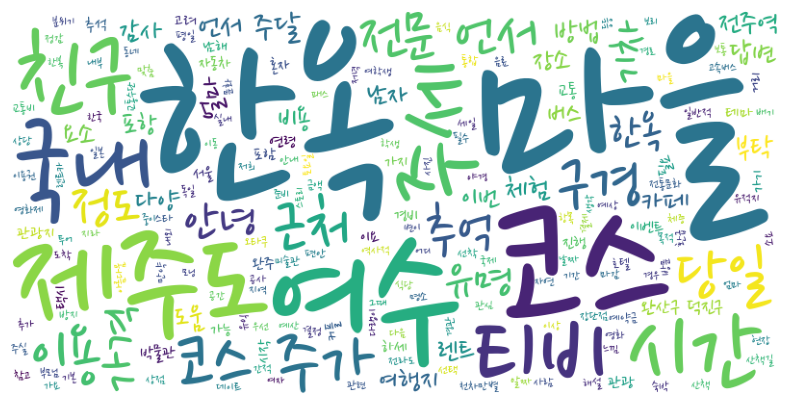

In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud1 = WordCloud(font_path='data/NanumPenScript-Regular.ttf',
                             background_color='white',
                             max_words=300,
                            #  relative_scaling=0.9,
                             stopwords=불용어,
                             width=800,
                             height=400)
wordcloud1 = wordcloud1.generate(' '.join(jeonju_list))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud1)
plt.axis('off')
plt.show()


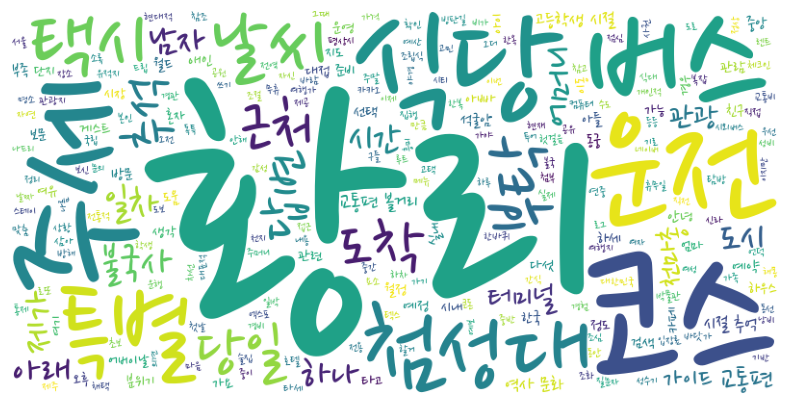

In [10]:
wordcloud2 = WordCloud(font_path='data/NanumPenScript-Regular.ttf',
                             background_color='white',
                             max_words=300,
                            #  relative_scaling=0.9,
                             stopwords=불용어,
                             width=800,
                             height=400)

wordcloud2 = wordcloud2.generate(' '.join(gyeongju_list))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud2)
plt.axis('off')
plt.show()


In [11]:
from gensim.models import Word2Vec

model_jeonju = Word2Vec(sentences=nouns_jeonju,
                        vector_size=100,
                        window=5,
                        min_count=2,
                        workers=1)

model_gyeongju = Word2Vec(sentences=nouns_gyeongju,
                          vector_size=100,
                          window=5,
                          min_count=2,
                          workers=1)


In [14]:
print("'전주'와 유사한 단어:")
print(model_jeonju.wv.most_similar('전주'))

print("'경주'와 유사한 단어:")
print(model_gyeongju.wv.most_similar('경주'))


'전주'와 유사한 단어:
[('여수', 0.40387818217277527), ('카페', 0.3895248472690582), ('볼만', 0.3657015860080719), ('여행', 0.31978100538253784), ('구경', 0.31974247097969055), ('이용', 0.3193214237689972), ('박', 0.3104412853717804), ('남해', 0.30692756175994873), ('코스', 0.29575565457344055), ('주가', 0.29323142766952515)]
'경주'와 유사한 단어:
[('어머니', 0.36587247252464294), ('계획', 0.36175477504730225), ('4', 0.34825047850608826), ('선택', 0.33109334111213684), ('추억', 0.28838425874710083), ('교통편', 0.28059592843055725), ('카페', 0.26261383295059204), ('날씨', 0.24046143889427185), ('당일', 0.23450393974781036), ('추천', 0.23121601343154907)]
